<a href="https://colab.research.google.com/github/diyeddin/asl-classifier/blob/main/asl_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import h5py
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
import os
import math

In [ ]:
# def load_data(filename, num_of_examples):
#     letter_to_num = {'A':0, 'B':1, 'C':2, 'D':3, 'E':4, 'F':5, 'G':6, 'H':7, 'I':8, 'K':9, 'L':10, 'M':11,
#                  'N':12, 'O':13, 'P':14, 'Q':15, 'R':16, 'S':17, 'T':18, 'U':19, 'V':20, 'W':21, 'X':22, 'Y':23} # without J and Z
#     labels = np.zeros((num_of_examples, 1))
#     data = np.zeros((num_of_examples, 128, 128))
#     i = 0
#     for file in os.listdir(filename):
#         for img in os.listdir(filename + "/" + file):
#             labels[i] = letter_to_num[file]
#             image_arr = np.asarray(Image.open(filename + "/" + file + "/" + img), dtype="int32")
#             data[i] = image_arr
#             i += 1

#     return data, labels

In [ ]:
# train_filename = '/content/drive/MyDrive/Colab Notebooks/dataset/train'
# test_filename = '/content/drive/MyDrive/Colab Notebooks/dataset/val'

# train_data_size = 9149 # 22880
# test_data_size = 1620 # 4053

# train_data, train_labels = load_data(train_filename, train_data_size)
# print("train data loaded.")
# test_data, test_labels = load_data(test_filename, test_data_size)
# print("test data loaded.")

In [ ]:
train_filename = "/content/drive/MyDrive/Colab Notebooks/datasets/asl_numbers/train_signs.h5"
test_filename = "/content/drive/MyDrive/Colab Notebooks/datasets/asl_numbers/test_signs.h5"

train_dataset = h5py.File(train_filename, "r")
test_dataset = h5py.File(test_filename, "r")

train_set_x_orig = np.array(train_dataset["train_set_x"][:])
train_set_y_orig = np.array(train_dataset["train_set_y"][:])

test_set_x_orig = np.array(test_dataset["test_set_x"][:])
test_set_y_orig = np.array(test_dataset["test_set_y"][:])

train_set_y = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
test_set_y = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))

train_set_x_orig = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T
test_set_x_orig = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T

train_set_x = train_set_x_orig/255
test_set_x = test_set_x_orig/255

In [ ]:
test_dataset["list_classes"][:]

array([0, 1, 2, 3, 4, 5])

In [ ]:
# train_data_final = np.reshape(train_data.T, (-1, train_data_size))/255
# train_labels = train_labels.T

# test_data_final = np.reshape(test_data.T, (-1, test_data_size))/255
# test_labels = test_labels.T

(-0.5, 63.5, 63.5, -0.5)

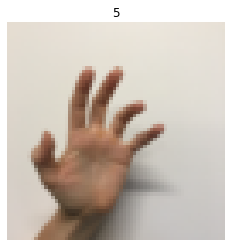

In [ ]:
# imsize_x, imsize_y = 128, 128
# index = 0
# plt.imshow(np.reshape(test_data_final[:, index:index+1], (imsize_x, imsize_y)).T, cmap="gray")

imsize_x, imsize_y = 64, 64
index = 20
plt.imshow(np.reshape(test_set_x[:, index:index+1], (imsize_x, imsize_y, 3)))
plt.title(test_set_y[0][index])
plt.axis("off")

In [ ]:
# tools

def relu(Z):
    return np.maximum(0, Z)

def relu_backward(Z):
    return (Z > 0) * 1

def softmax(Z):
    #t = np.exp(Z - np.max(Z))
    t = np.exp(Z)
    return t / t.sum(axis=0)

def softmax_backward(Z):
    pass

def one_hot_encoder(Y, depth):
    num_examples = Y.shape[1]
    OH_Y = np.zeros((depth, num_examples))
    
    for i in range(num_examples):
        OH_Y[:, i:i+1][int(Y[0][i])] = 1

    return OH_Y

def shuffle(X, Y):
    m = X.shape[1]
    permutation = list(np.random.permutation(m))
    shuffled_X = X[:, permutation]
    shuffled_Y = Y[:, permutation]#.reshape((C, m))

    return shuffled_X, shuffled_Y 

def random_mini_batches(X, Y, mini_batch_size=64):
    m = X.shape[1]
    mini_batches = []
    shuffled_X, shuffled_Y = shuffle(X, Y)
    inc = mini_batch_size

    num_complete_minibatches = math.floor(m / mini_batch_size)
    for k in range(0, num_complete_minibatches):
        mini_batch_X = shuffled_X[:, k*inc : (k + 1)*inc]
        mini_batch_Y = shuffled_Y[:, k*inc : (k + 1)*inc]

        mini_batch = (mini_batch_X, mini_batch_Y)
        mini_batches.append(mini_batch)
    

    if m % mini_batch_size != 0:
        mini_batch_X = shuffled_X[:, (k + 1)*inc:]
        mini_batch_Y = shuffled_Y[:, (k + 1)*inc:]

        mini_batch = (mini_batch_X, mini_batch_Y)
        mini_batches.append(mini_batch)

    return mini_batches

def update_lr(learning_rate0, epochNumber, decayRate):
    return (1/(1 + decayRate*epochNumber))*learning_rate0

In [ ]:
def initialize_parameters(layer_dims):
    L = len(layer_dims)
    parameters = {}
    for l in range(1, L):
        parameters['W' + str(l)] = np.random.randn(layer_dims[l], layer_dims[l-1])*np.sqrt(2/layer_dims[l-1]) # He initialization
        parameters['b' + str(l)] = np.zeros((layer_dims[l], 1))

    return parameters

def initialize_adam(parameters):
    L = len(parameters) // 2
    v = {}
    s = {}

    for l in range(1, L + 1):
        v["dW" + str(l)] = np.zeros(parameters['W' + str(l)].shape)
        v["db" + str(l)] = np.zeros(parameters['b' + str(l)].shape)
        s["dW" + str(l)] = np.zeros(parameters['W' + str(l)].shape)
        s["db" + str(l)] = np.zeros(parameters['b' + str(l)].shape)
    
    return v, s

In [ ]:
def forward_propagation(X, parameters):
    A = X
    caches = []
    L = len(parameters) // 2
    
    for l in range(1, L):
        A_prev = A
        W = parameters['W' + str(l)]
        b = parameters['b' + str(l)]
        Z = np.dot(W, A_prev) + b
        A = relu(Z)
        
        caches.append((A_prev, W, b, Z))
        
    W = parameters['W' + str(L)]
    b = parameters['b' + str(L)]
    Z = np.dot(W, A) + b
    AL = softmax(Z)
    
    caches.append((A, W, b, Z))
    
    return AL, caches

In [ ]:
def compute_cost(AL, Y):
    m = Y.shape[1]
    loss = -np.sum(np.multiply(Y, np.log(AL)), axis=1)
    cost = 1/m * np.sum(loss, axis=0)
    
    return cost


def cross_entropy(AL, Y):
    loss = -np.sum(Y*np.log(AL))
    return loss/float(AL.shape[1]) # it waz AL.shape[0]

In [ ]:
def backward_propagation(AL, Y, caches):
    grads = {}
    L = len(caches)
    Y = Y.reshape(AL.shape)
    m = AL.shape[1]

    A_prev, W, b, Z = caches[L - 1] # (A_prev, W, b, Z)
    #m = A_prev.shape[1]
    dZL = AL - Y # no need for softmax derivative smh
    grads["dA" + str(L - 1)] = np.dot(W.T, dZL)
    grads["dW" + str(L)] = 1/m*np.dot(dZL, A_prev.T)
    grads["db" + str(L)] = 1/m*np.sum(dZL, axis=1, keepdims=True)
    
    for l in reversed(range(L - 1)):
        A_prev, W, b, Z = caches[l]
        #m = A_prev.shape[1]
        dZ = grads["dA" + str(l + 1)] * relu_backward(Z)
        grads["dA" + str(l)] = np.dot(W.T, dZ)
        grads["dW" + str(l + 1)] = 1/m*np.dot(dZ, A_prev.T)
        grads["db" + str(l + 1)] = 1/m*np.sum(dZ, axis=1, keepdims=True)
        
    return grads

In [ ]:
def update_parameters(parameters, grads, learning_rate):
    L = len(parameters) // 2
    
    for l in range(L):
        parameters['W' + str(l + 1)] = parameters['W' + str(l + 1)] - learning_rate*grads["dW" + str(l + 1)]
        parameters['b' + str(l + 1)] = parameters['b' + str(l + 1)] - learning_rate*grads["db" + str(l + 1)]
    return parameters

def adam_optimization(parameters, grads, v, s, t, learning_rate=0.01, beta1=0.9, beta2=0.999, epsilon=1e-8):
    L = len(parameters) // 2
    v_corrected = {}
    s_corrected = {}

    for l in range(1, L + 1):
        # momentum with beta1
        v["dW" + str(l)] = beta1*v["dW" + str(l)] + (1 - beta1)*grads["dW" + str(l)]
        v["db" + str(l)] = beta1*v["db" + str(l)] + (1 - beta1)*grads["db" + str(l)]
        # bias-corrected
        v_corrected["dW" + str(l)] = v["dW" + str(l)]/(1 - beta1**t)
        v_corrected["db" + str(l)] = v["db" + str(l)]/(1 - beta1**t)

        # RMSprop with beta2
        s["dW" + str(l)] = beta2*s["dW" + str(l)] + (1 - beta2)*(grads["dW" + str(l)]**2)
        s["db" + str(l)] = beta2*s["db" + str(l)] + (1 - beta2)*(grads["db" + str(l)]**2)
        # bias-corrected
        s_corrected["dW" + str(l)] = s["dW" + str(l)]/(1 - beta2**t)
        s_corrected["db" + str(l)] = s["db" + str(l)]/(1 - beta2**t)

        # update parameters
        parameters['W' + str(l)] = parameters['W' + str(l)] - learning_rate*(v_corrected["dW" + str(l)]/(np.sqrt(s_corrected["dW" + str(l)]) + epsilon))
        parameters['b' + str(l)] = parameters['b' + str(l)] - learning_rate*(v_corrected["db" + str(l)]/(np.sqrt(s_corrected["db" + str(l)]) + epsilon)) 

    return parameters, v, s, v_corrected, s_corrected

In [ ]:
def model(X, Y, layer_dims, learning_rate=0.0007, mini_batch_size=64, beta1=0.9, beta2=0.999,
          epsilon=1e-8, num_epochs=5000, print_cost=True, decay=None, decay_rate=1):
    costs = []
    t = 0 # adam counter
    m = X.shape[1]
    learning_rate0 = learning_rate

    # initialize params
    parameters = initialize_parameters(layer_dims)
    
    # initialize optimizer
    v, s = initialize_adam(parameters)

    for i in range(0, num_epochs):

        minibatches = random_mini_batches(X, Y, mini_batch_size)
        cost_total = 0
        
        for minibatch in minibatches:

            # select minibatch
            (minibatch_X, minibatch_Y) = minibatch

            # forward
            AL, caches = forward_propagation(minibatch_X, parameters)
            # compute cost
            cost_total += cross_entropy(AL, minibatch_Y) 
            # cost_total += compute_cost(AL, minibatch_Y)
            # backward, compute gradients
            grads = backward_propagation(AL, minibatch_Y, caches)
            # update parameters, gradient descent
            # parameters = update_parameters(parameters, grads, learning_rate)
            # update parameters, adam
            t = t + 1 # adam counter
            parameters, v, s, _, _ = adam_optimization(parameters, grads, v, s, t, learning_rate, beta1, beta2, epsilon) 

        
        cost_avg = cost_total / m
        if decay:
          learning_rate = decay(learning_rate0, i, decay_rate)
        if print_cost and i % 100 == 0: # that was 1000
            print ("Cost after epoch %i: %f" %(i, cost_avg))
            if decay:
                print("learning rate after epoch %i: %f"%(i, learning_rate))
        if print_cost and i % 1 == 0: # it was 100
            costs.append(cost_avg)
    
    plt.plot(costs)
    plt.ylabel('cost')
    plt.xlabel('iterations (per hundreds)')
    plt.title("Learning rate =" + str(learning_rate))
    plt.show()
    return parameters, costs


In [ ]:
C = 6
layer_dims = [64*64*3, 25, 15, 12, C]
# layer_dims = [64*64*3, 32, 32, 32, 16, 16, C]

In [ ]:
train_set_y_oh = one_hot_encoder(train_set_y, C)

Cost after epoch 0: 0.316050
learning rate after epoch 0: 0.010000
Cost after epoch 100: 0.028207
learning rate after epoch 100: 0.000099
Cost after epoch 200: 0.028205
learning rate after epoch 200: 0.000050
Cost after epoch 300: 0.028205
learning rate after epoch 300: 0.000033
Cost after epoch 400: 0.028204
learning rate after epoch 400: 0.000025
Cost after epoch 500: 0.028204
learning rate after epoch 500: 0.000020
Cost after epoch 600: 0.028204
learning rate after epoch 600: 0.000017
Cost after epoch 700: 0.028204
learning rate after epoch 700: 0.000014
Cost after epoch 800: 0.028204
learning rate after epoch 800: 0.000012
Cost after epoch 900: 0.028204
learning rate after epoch 900: 0.000011


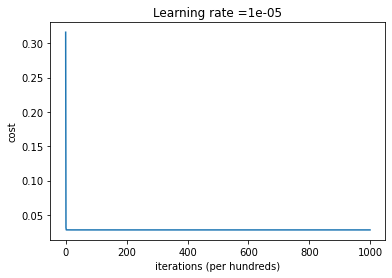

In [ ]:
parameters, costs = model(train_set_x, train_set_y_oh, layer_dims, learning_rate=0.01, num_epochs=1000, decay = update_lr)

In [ ]:
# i = 0
# outfile = "parameters{}.npz".format(i)
# np.savez(outfile, **parameters)
# i += 1

In [ ]:
pred, caches = forward_propagation(test_set_x, parameters)

m = pred.shape[1]
correct = 0
for i in range(m):
    if np.argmax(pred[:, i:i+1]) == test_set_y[0][i]:
        correct += 1
    
percentage = (correct / m) * 100

In [ ]:
print(percentage)

16.666666666666664
